<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Aprendizaje Automático Avanzado</h1>
    <h3>Árboles de Decisión (Decision Trees)</h3>
    
</div>

> Los **árboles de decisión** es uno de los modelos más intuitivos e interpretables del Machine Learning. Además de ser útiles por sí mismos, son el **bloque de construcción** de los métodos de ensamble más potentes (Random Forest y Gradient Boosting), por lo que entenderlos bien es esencial dentro de los **algoritmos avanzados**.

## ¿Qué es un árbol de decisión?

Un **árbol de decisión** es un modelo que predice el valor de una variable objetivo **aprendiendo reglas de decisión sencillas** (`si ... entonces ...`) inferidas a partir de los datos.

>  **Analogía cotidiana:** decidir si llevar paraguas. *¿Está nublado?* → Sí → *¿La humedad es alta?* → Sí → **llevar paraguas**. Cada pregunta divide el problema hasta llegar a una decisión.

El modelo tiene forma de árbol invertido: empieza en un **nodo raíz** (arriba) y se ramifica mediante preguntas sobre las variables hasta llegar a las **hojas** (abajo), que contienen la predicción final.

Es un modelo **no paramétrico**: no asume una forma fija (como una recta) para la relación entre variables; la estructura crece según los datos.

Un ejemplo de árbol ya entrenado (inspirado en el dataset **Titanic** que usaremos más abajo):

```mermaid
flowchart TD
    A{¿sexo = mujer?} -->|Sí| B{¿clase <= 2?}
    A -->|No| C{¿edad < 6.5?}
    B -->|Sí| D[Sobrevive]
    B -->|No| E{¿tarifa < 20?}
    C -->|Sí| F[Sobrevive]
    C -->|No| G[No sobrevive]
    E -->|Sí| H[No sobrevive]
    E -->|No| I[Sobrevive]
```

## 2. Anatomía y terminología

```mermaid
flowchart TD
    R[Nodo raíz<br/>toda la muestra] --> N1[Nodo interno<br/>pregunta sobre una variable]
    R --> N2[Nodo interno]
    N1 --> L1[Hoja: clase A]
    N1 --> L2[Hoja: clase B]
    N2 --> L3[Hoja: clase A]
    N2 --> L4[Hoja: clase B]
```

| Término | Significado |
|---|---|
| **Nodo raíz** (*root*) | Nodo superior; contiene toda la muestra antes de dividir. |
| **Nodo interno** | Nodo con una condición de división sobre una variable. |
| **Rama** (*branch*) | Resultado de una condición (verdadero/falso). |
| **Hoja** (*leaf*) | Nodo terminal; entrega la predicción (clase o valor). |
| **Profundidad** (*depth*) | Número de niveles desde la raíz hasta la hoja más lejana. |
| **División** (*split*) | Partición de los datos según una condición. |

## ¿Cómo decide dónde dividir?

En cada nodo, el árbol prueba todas las variables y umbrales, y elige la división que produce nodos hijos lo más **"puros"** posible (que contengan mayoritariamente una sola clase). La *pureza* se mide con una **función de impureza**.

### Para clasificación

**Índice de Gini**: probabilidad de clasificar mal un elemento tomado al azar:
$$Gini = 1 - \sum_{i=1}^{C} p_i^2$$

**Entropía** (ganancia de información):
$$H = - \sum_{i=1}^{C} p_i \log_2 p_i$$

donde $p_i$ es la proporción de la clase $i$ en el nodo y $C$ el número de clases. Ambas valen **0** cuando el nodo es puro (una sola clase) y son **máximas** cuando las clases están equilibradas.

La **ganancia** de una división es la reducción de impureza:
$$\text{Ganancia} = I(\text{padre}) - \sum_{k} \frac{n_k}{n}\, I(\text{hijo}_k)$$

### Para regresión
Se minimiza el **error cuadrático medio** (MSE) o el **error absoluto medio** (MAE) dentro de cada nodo; la predicción de una hoja es el **promedio** de los valores que caen en ella.

Veamos numéricamente cómo cambia la impureza de un nodo según su composición de clases:

In [1]:
import numpy as np

def gini(p):
    p = np.array(p)
    return 1 - np.sum(p**2)

def entropia(p):
    p = np.array(p)
    p = p[p > 0]                     # evita log(0)
    return -np.sum(p * np.log2(p))

for prop in ([1.0, 0.0], [0.9, 0.1], [0.7, 0.3], [0.5, 0.5]):
    print(f'clases {prop} -> Gini={gini(prop):.3f} | Entropía={entropia(prop):.3f}')

clases [1.0, 0.0] -> Gini=0.000 | Entropía=-0.000
clases [0.9, 0.1] -> Gini=0.180 | Entropía=0.469
clases [0.7, 0.3] -> Gini=0.420 | Entropía=0.881
clases [0.5, 0.5] -> Gini=0.500 | Entropía=1.000


> Observemos que: un nodo **puro** `[1.0, 0.0]` tiene impureza 0; un nodo **totalmente mezclado** `[0.5, 0.5]` alcanza el máximo (Gini = 0.5, Entropía = 1.0). El árbol busca divisiones que **bajen** este valor.

## 4. El algoritmo CART

scikit-learn implementa **CART** (*Classification And Regression Trees*), que construye el árbol de forma **recursiva y voraz** (*greedy*):

1. En el nodo actual, evalúa **todas** las variables y umbrales posibles.
2. Elige la división que **maximiza la reducción de impureza**.
3. Divide los datos y repite el proceso en cada hijo.
4. **Se detiene** cuando: el nodo es puro, se alcanza `max_depth`, hay muy pocas muestras (`min_samples_split` / `min_samples_leaf`), o ninguna división mejora.

>  *Greedy* significa que toma la mejor decisión **local** en cada paso, sin garantizar el árbol globalmente óptimo (encontrar el óptimo es un problema NP-completo).

## Ejemplo real (clasificación):

Usaremos el dataset **Titanic** (real, con datos de pasajeros reales) para predecir la **supervivencia**. Contiene variables numéricas y categóricas, ideales para árboles.

In [2]:
import pandas as pd
from sklearn.datasets import fetch_openml

# Dataset real de OpenML (se descarga y cachea la primera vez)
data = fetch_openml('titanic', version=1, as_frame=True)
df = data.frame

y = df['survived'].astype(int)
X = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()

# Preprocesamiento: codificar categóricas e imputar faltantes
X['pclass'] = X['pclass'].astype(int)
X['sex'] = (X['sex'] == 'female').astype(int)                 # 1 = mujer
X['embarked'] = X['embarked'].fillna('S')
X = pd.get_dummies(X, columns=['embarked'], drop_first=True)
X['age'] = X['age'].astype(float).fillna(X['age'].astype(float).median())
X['fare'] = X['fare'].astype(float).fillna(X['fare'].astype(float).median())

print('Forma:', X.shape)
X.head()

Forma: (1309, 8)


,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,1,1,29.0000,0,0,211.3375,False,True
1,1,0,0.9167,1,2,151.5500,False,True
2,1,1,2.0000,1,2,151.5500,False,True
3,1,0,30.0000,1,2,151.5500,False,True
4,1,1,25.0000,1,2,151.5500,False,True


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)
print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print()
print(classification_report(y_test, pred, target_names=['No sobrevive', 'Sobrevive']))

Accuracy: 0.8359

              precision    recall  f1-score   support

No sobrevive       0.85      0.90      0.87       162
   Sobrevive       0.81      0.74      0.77       100

    accuracy                           0.84       262
   macro avg       0.83      0.82      0.82       262
weighted avg       0.83      0.84      0.83       262



### Visualizar el árbol aprendido
Una gran ventaja: podemos **ver** exactamente las reglas que aprendió.

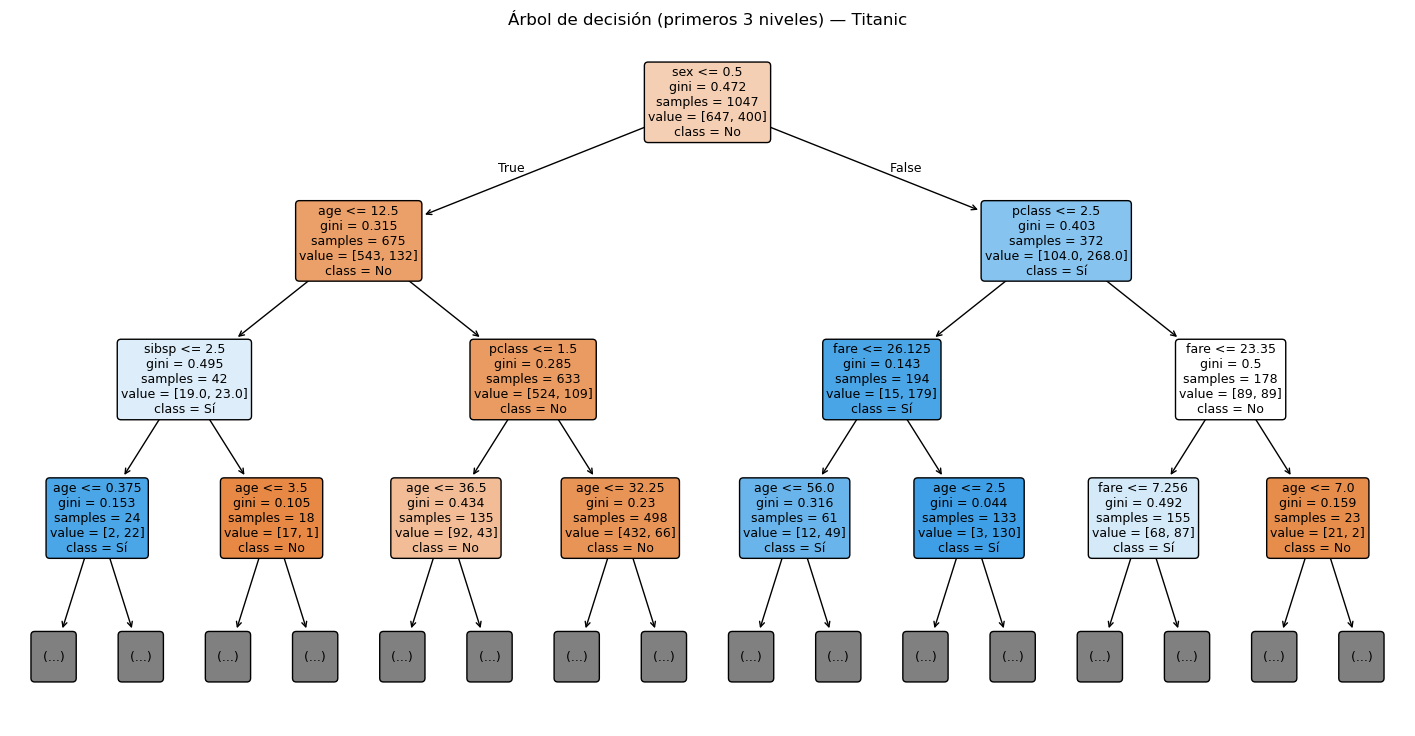

In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 9))
plot_tree(
    clf, feature_names=list(X.columns), class_names=['No', 'Sí'],
    filled=True, rounded=True, fontsize=9, max_depth=3,
)
plt.title('Árbol de decisión (primeros 3 niveles) — Titanic')
plt.show()

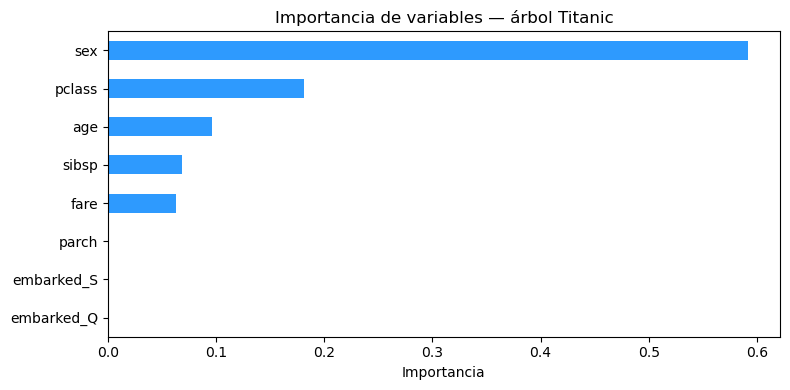

In [5]:
# Importancia de variables (reducción total de impureza aportada por cada una)
importancias = pd.Series(clf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 4))
importancias.plot.barh(color='#2E9AFE')
plt.xlabel('Importancia')
plt.title('Importancia de variables — árbol Titanic')
plt.tight_layout()
plt.show()

## Ejemplo real (regresión): precios de vivienda en California

Los árboles también predicen **valores continuos**. Usaremos **California Housing** (20 640 viviendas reales) para predecir el precio mediano.

In [6]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

cal = fetch_california_housing(as_frame=True)
Xr, yr = cal.data, cal.target
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=42)

reg = DecisionTreeRegressor(max_depth=6, random_state=42).fit(Xr_tr, yr_tr)
pred_r = reg.predict(Xr_te)

print('RMSE:', round(np.sqrt(mean_squared_error(yr_te, pred_r)), 4))
print('R2  :', round(r2_score(yr_te, pred_r), 4))

RMSE: 0.7052
R2  : 0.6205


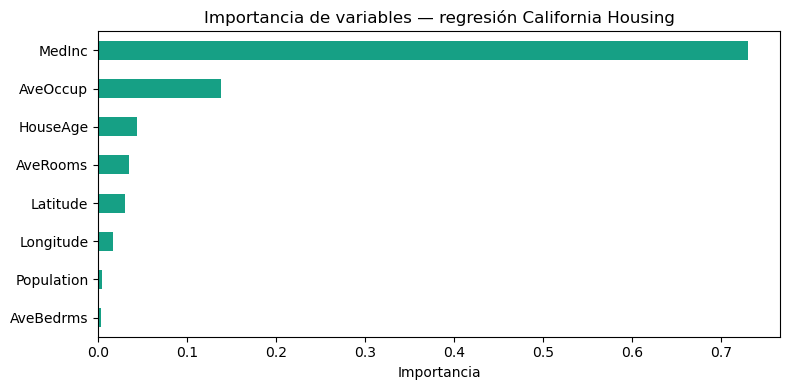

In [7]:
# ¿Qué variables usa más el árbol de regresión?
imp_r = pd.Series(reg.feature_importances_, index=Xr.columns).sort_values()
plt.figure(figsize=(8, 4))
imp_r.plot.barh(color='#16a085')
plt.xlabel('Importancia')
plt.title('Importancia de variables — regresión California Housing')
plt.tight_layout()
plt.show()

## Sobreajuste e hiperparámetros

Un árbol sin restricciones puede crecer hasta **memorizar** los datos de entrenamiento (hojas con 1 muestra) → **sobreajuste**. Los hiperparámetros controlan su complejidad:

| Hiperparámetro | Efecto | Para regularizar |
|---|---|---|
| `max_depth` | Profundidad máxima | **Reducir** |
| `min_samples_split` | Mínimo de muestras para dividir | Aumentar |
| `min_samples_leaf` | Mínimo de muestras por hoja | Aumentar |
| `max_features` | Variables consideradas por división | Reducir |
| `ccp_alpha` | Poda por complejidad (*cost-complexity pruning*) | Aumentar |

Veamos el efecto de `max_depth` sobre el rendimiento en entrenamiento vs. validación:

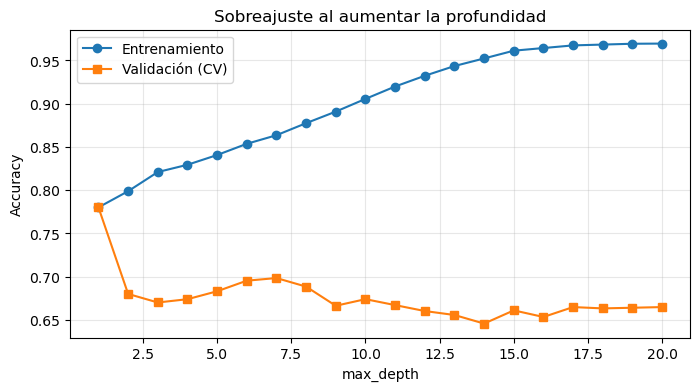

In [8]:
from sklearn.model_selection import validation_curve

depths = range(1, 21)
train_sc, val_sc = validation_curve(
    DecisionTreeClassifier(random_state=42), X, y,
    param_name='max_depth', param_range=depths, cv=5, scoring='accuracy',
)

plt.figure(figsize=(8, 4))
plt.plot(depths, train_sc.mean(axis=1), 'o-', label='Entrenamiento')
plt.plot(depths, val_sc.mean(axis=1), 's-', label='Validación (CV)')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Sobreajuste al aumentar la profundidad')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

> Al aumentar la profundidad, el *accuracy* de entrenamiento sube casi a 1.0, pero el de validación se estanca o **cae**: eso es **sobreajuste**. El mejor `max_depth` es donde la curva de validación alcanza su máximo.

### Ventajas y desventajas

|  Ventajas |  Desventajas |
|---|---|
| Muy **interpretables** (reglas visibles) | **Inestables**: pequeños cambios en datos → árbol distinto |
| No requieren escalar las variables | Tienden al **sobreajuste** si no se podan |
| Manejan variables numéricas y categóricas | Fronteras de decisión "escalonadas" (ejes) |
| Capturan relaciones **no lineales** e interacciones | Un solo árbol suele ser **poco preciso** |
| Rápidos de entrenar y predecir | Sesgo hacia variables con muchos niveles |

>  La **inestabilidad** y el **sobreajuste** de un árbol individual son precisamente los problemas que resuelven los **ensambles** (Random Forest, Boosting).

## Interpretabilidad: extracción de las reglas aprendidas

Podemos exportar el árbol como **reglas de texto** legibles.

In [9]:
from sklearn.tree import export_text

# Árbol pequeño para que las reglas sean legibles
arbol_simple = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
print(export_text(arbol_simple, feature_names=list(X.columns)))

|--- sex <= 0.50
|   |--- age <= 12.50
|   |   |--- sibsp <= 2.50
|   |   |   |--- class: 1
|   |   |--- sibsp >  2.50
|   |   |   |--- class: 0
|   |--- age >  12.50
|   |   |--- pclass <= 1.50
|   |   |   |--- class: 0
|   |   |--- pclass >  1.50
|   |   |   |--- class: 0
|--- sex >  0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 26.12
|   |   |   |--- class: 1
|   |   |--- fare >  26.12
|   |   |   |--- class: 1
|   |--- pclass >  2.50
|   |   |--- fare <= 23.35
|   |   |   |--- class: 1
|   |   |--- fare >  23.35
|   |   |   |--- class: 0



## Conexión con los métodos de ensamble

Un árbol individual es **débil e inestable**, pero es un **excelente bloque de construcción**. Combinando muchos árboles obtenemos los algoritmos más potentes para datos estructurados:

```mermaid
flowchart LR
    T[Árbol de decisión] --> RF[Random Forest<br/>bagging de árboles]
    T --> GB[Gradient Boosting<br/>boosting de árboles]
    RF --> X1[XGBoost / LightGBM / CatBoost]
    GB --> X1
```


- Un **árbol de decisión** aprende reglas `si/entonces` dividiendo los datos para maximizar la **pureza** de los nodos (Gini/entropía en clasificación, MSE en regresión).
- Usa el algoritmo **CART**, recursivo y voraz, con criterios de parada.
- Es **interpretable** y flexible, pero **inestable** y propenso al **sobreajuste** (se controla con `max_depth`, `min_samples_leaf`, poda, etc.).
- Es la **base** de Random Forest y Gradient Boosting.

[scikit-learn — Decision Trees](https://scikit-learn.org/stable/modules/tree.html)
